# **Spoticore Stage 2.2**: _Manual Backpropagation_

A manual implementation of the backpropagation flow during a backward pass. Here, we stop relying on `loss.backward()` because it is considered to be a [leaky abstraction](https://en.wikipedia.org/wiki/Leaky_abstraction). The goal of this notebook is to gain a deeper understanding and intuition into the nuances of how gradients flow backwards in a computational graph involving tensors.

References:

- [Bessel's Correction](https://math.oxford.emory.edu/site/math117/besselCorrection/)

Note:

> This notebook scaffold is taken from Andrej Kaparthy's [makemore lecture](https://www.youtube.com/watch?v=q8SA3rM6ckI). The data
> preprocessing steps have been refactored to handle our own custom dataset of spotify lyrics.


In [1]:
import random
import torch
import torch.nn.functional as F

import matplotlib.pyplot as plt

%matplotlib inline


from reader import read_all_unique_words

In [2]:
# read in all the words.
words = read_all_unique_words()


print("total words:", len(words))
print("max word length:", max(len(w) for w in words))
print("example set of words:", words[:8])

total words: 82350
max word length: 20
example set of words: ['organizations', 'omegalomaniac', 'briz', 'nickelodeon', 'knowning', 'appeared', 'woved', 'ruggedest']


In [3]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set("".join(words))))
stoi = {s: i + 1 for i, s in enumerate(chars)}
stoi["."] = 0

itos = {i: s for s, i in stoi.items()}
vocab_size = len(itos)
print(f"{itos = }")
print(f"{vocab_size = }")

itos = {1: '0', 2: '1', 3: '2', 4: '3', 5: '4', 6: '5', 7: '6', 8: '7', 9: '8', 10: '9', 11: 'a', 12: 'b', 13: 'c', 14: 'd', 15: 'e', 16: 'f', 17: 'g', 18: 'h', 19: 'i', 20: 'j', 21: 'k', 22: 'l', 23: 'm', 24: 'n', 25: 'o', 26: 'p', 27: 'q', 28: 'r', 29: 's', 30: 't', 31: 'u', 32: 'v', 33: 'w', 34: 'x', 35: 'y', 36: 'z', 0: '.'}
vocab_size = 37


In [4]:
# build the dataset
block_size = (
    3  # context length: how many characters do we take to predict the next one?
)


def build_dataset(words):
    X, Y = [], []

    for w in words:
        context = [0] * block_size
        for ch in w + ".":
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]  # crop and append

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y


random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])  # 80%
Xdev, Ydev = build_dataset(words[n1:n2])  # 10%
Xte, Yte = build_dataset(words[n2:])  # 10%

torch.Size([532445, 3]) torch.Size([532445])
torch.Size([66604, 3]) torch.Size([66604])
torch.Size([66121, 3]) torch.Size([66121])


In [5]:
# utility function we will use later when comparing manual gradients to PyTorch gradients
def cmp(s, dt, t):
    ex = torch.all(dt == t.grad).item()
    app = torch.allclose(dt, t.grad)
    maxdiff = (dt - t.grad).abs().max().item()
    print(
        f"{s:15s} | exact: {str(ex):5s} | approximate: {str(app):5s} | maxdiff: {maxdiff}"
    )

In [6]:
n_embd = 10  # the dimensionality of the character embedding vectors
n_hidden = 64  # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647)  # for reproducibility
C = torch.randn((vocab_size, n_embd), generator=g)
# Layer 1
W1 = (
    torch.randn((n_embd * block_size, n_hidden), generator=g)
    * (5 / 3)
    / ((n_embd * block_size) ** 0.5)
)
b1 = (
    torch.randn(n_hidden, generator=g) * 0.1
)  # using b1 just for fun, it's useless because of BN
# Layer 2
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.1
b2 = torch.randn(vocab_size, generator=g) * 0.1
# BatchNorm parameters
bngain = torch.randn((1, n_hidden)) * 0.1 + 1.0
bnbias = torch.randn((1, n_hidden)) * 0.1

# Note: I am initializating many of these parameters in non-standard ways
# because sometimes initializating with e.g. all zeros could mask an incorrect
# implementation of the backward pass.

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters))  # number of parameters in total
for p in parameters:
    p.requires_grad = True

4887


In [7]:
batch_size = 32
n = batch_size  # a shorter variable also, for convenience
# construct a minibatch
ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
Xb, Yb = Xtr[ix], Ytr[ix]  # batch X,Y

In [8]:
# forward pass, "chunkated" into smaller steps that are possible to backward one at a time

emb = C[Xb]  # embed the characters into vectors
embcat = emb.view(emb.shape[0], -1)  # concatenate the vectors
# Linear layer 1
hprebn = embcat @ W1 + b1  # hidden layer pre-activation
# BatchNorm layer
bnmeani = 1 / n * hprebn.sum(0, keepdim=True)
bndiff = hprebn - bnmeani
bndiff2 = bndiff**2
bnvar = (
    1 / (n - 1) * (bndiff2).sum(0, keepdim=True)
)  # note: Bessel's correction (dividing by n-1, not n)
bnvar_inv = (bnvar + 1e-5) ** -0.5
bnraw = bndiff * bnvar_inv
hpreact = bngain * bnraw + bnbias
# Non-linearity
h = torch.tanh(hpreact)  # hidden layer
# Linear layer 2
logits = h @ W2 + b2  # output layer
# cross entropy loss (same as F.cross_entropy(logits, Yb))
logit_maxes = logits.max(1, keepdim=True).values
norm_logits = logits - logit_maxes  # subtract max for numerical stability
counts = norm_logits.exp()
counts_sum = counts.sum(1, keepdims=True)
counts_sum_inv = (
    counts_sum**-1
)  # if I use (1.0 / counts_sum) instead then I can't get backprop to be bit exact...
probs = counts * counts_sum_inv
logprobs = probs.log()
loss = -logprobs[range(n), Yb].mean()

# PyTorch backward pass
for p in parameters:
    p.grad = None
for t in [
    logprobs,
    probs,
    counts,
    counts_sum,
    counts_sum_inv,  # afaik there is no cleaner way
    norm_logits,
    logit_maxes,
    logits,
    h,
    hpreact,
    bnraw,
    bnvar_inv,
    bnvar,
    bndiff2,
    bndiff,
    hprebn,
    bnmeani,
    embcat,
    emb,
]:
    t.retain_grad()
loss.backward()
loss

tensor(3.8093, grad_fn=<NegBackward0>)

## Exercise 1

Backprop through the whole thing manually, backpropagating through exactly all of the variables, as they are defined in the forward pass above, one by one.


In [9]:
# loss = -logprobs[range(n), Yb].mean()
loss.shape, logprobs.shape, Yb.shape

(torch.Size([]), torch.Size([32, 37]), torch.Size([32]))

In [10]:
# non-indexed elements dont affect the loss so their gradient is 0
dlogprobs = torch.zeros_like(logprobs)
# update indexed elements that influence the loss function
dlogprobs[range(n), Yb] = (-1.0 / n) * 1

In [11]:
# logprobs = probs.log()
# notice how this operation boosts the gradient for elements that have a low probability
dprobs = (1.0 / probs) * dlogprobs

In [12]:
# probs = counts * counts_sum_inv
probs.shape, counts.shape, counts_sum_inv.shape

(torch.Size([32, 37]), torch.Size([32, 37]), torch.Size([32, 1]))

In [13]:
# Grad for product: counts * counts_sum_inv
# During backward gradient flow, all the gradients of one row of counts*dprobs
# lead to one element of dcounts_sum_inv
# ? We sum along dimension 1 (columns) because that is the dimension broadcasting replicated
# ? across during implicit broadcasting in forward pass
dcounts_sum_inv = (counts * dprobs).sum(1, keepdims=True)

dcounts = counts_sum_inv * dprobs

In [14]:
# counts_sum_inv = counts_sum**-1#
dcounts_sum = (-1.0 * counts_sum**-2) * dcounts_sum_inv

In [15]:
# counts_sum = counts.sum(1, keepdims=True)
counts_sum.shape, counts.shape

(torch.Size([32, 1]), torch.Size([32, 37]))

In [16]:
# gradient flows backwards for addition operations
dcounts += torch.ones_like(counts) * dcounts_sum

In [17]:
# counts = norm_logits.exp()
dnorm_logits = norm_logits.exp() * dcounts

In [18]:
# norm_logits = logits - logit_maxes
dlogit_maxes = (-1.0 * dnorm_logits).sum(1, keepdims=True)

# clone to avoid mutating the same tensor storage as dnorm_logits
dlogits = dnorm_logits.clone()

In [19]:
# logit_maxes = logits.max(1, keepdim=True).values
max_indices = F.one_hot(logits.max(1).indices, num_classes=logits.shape[1])

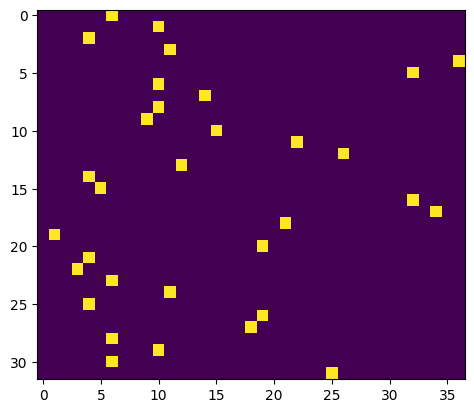

In [20]:
# need to scatter dlogits to the max element in logits
plt.imshow(max_indices)

In [21]:
dlogits += max_indices * dlogit_maxes

### Gradients in matrix multiplication

<img src = "images/matrixmul-grad.jpeg" width = "500px">


### Trick to find shape of operands for multiplication

Observe that:

> In order for any matrix multiplication to work, the shapes of the two matrices _m1_, _m2_ must be such that:
>
> Column size of _m1_ = row size of _m2_.

This gives insight into which matrix requires transpostion for the multiplication to be valid.

$$\text{logits} = h @ W2 + b2$$


In [22]:
logits.shape, h.shape, W2.shape, b2.shape

(torch.Size([32, 37]),
 torch.Size([32, 64]),
 torch.Size([64, 37]),
 torch.Size([37]))

For example, let us calculate `dh`.

Firstly, `dh` will have the same shape as `h` [32, 64]. Secondly, we know `dh` is derived from a matrix multiplication between `dlogits` and `W2`.

`dlogits` has shape [32, 37] and `W2` has shape [64,37]. Transposing `W2` results in a [37, 64] matrix.

Therefore, in order to get a [32,64] shaped output matrix; the order of operations should be $dlogits @ W2^T$.


### Broadcast operations require summing dimensions in backward pass

When a smaller bias vector is broadcast to match a larger tensor's shape in the forward pass, the bias vector gets "copied" across multiple rows/columns depending on broadcast rules.

During backprop, gradients flow back through each of those positions independently. In the forward pass, all those positions originally came from the same parameter, so we must **sum all their gradients** to get the total gradient for that parameter.

Basically, if output gradient shape does not match the parameter shape, we should sum along the dimensions that were broadcast during the forward pass.

**Example:**

Consider `logits = h @ W2 + b2` where `b2` has shape [37].

- During forward pass: `b2` is broadcast from [37] to [32, 37] to add with each row.
- During backprop: `dlogits` has shape [32, 37], but we need `db2` to be [37].
- Solution: Sum along dimension 0 (the batch dimension): `db2 = dlogits.sum(0)`.

This accumulates all 32 gradient contributions that flowed through the broadcast copies of `b2`.


In [23]:
# logits = h @ W2 + b2
logits.shape, h.shape, W2.shape, b2.shape

(torch.Size([32, 37]),
 torch.Size([32, 64]),
 torch.Size([64, 37]),
 torch.Size([37]))

In [24]:
dh = dlogits @ W2.T
dW2 = h.T @ dlogits
db2 = dlogits.sum(0)

In [25]:
# h = torch.tanh(hpreact)
h.shape, hpreact.shape

(torch.Size([32, 64]), torch.Size([32, 64]))

In [26]:
dhpreact = (1 - h**2) * dh

In [27]:
# hpreact = bngain * bnraw + bnbias
hpreact.shape, bngain.shape, bnraw.shape, bnbias.shape

(torch.Size([32, 64]),
 torch.Size([1, 64]),
 torch.Size([32, 64]),
 torch.Size([1, 64]))

In [28]:
dbngain = (bnraw * dhpreact).sum(0, keepdims=True)
dbnbias = dhpreact.sum(0, keepdim=True)
dbnraw = bngain * dhpreact

In [29]:
# bnraw = bndiff * bnvar_inv
bnraw.shape, bndiff.shape, bnvar_inv.shape

(torch.Size([32, 64]), torch.Size([32, 64]), torch.Size([1, 64]))

In [30]:
dbnvar_inv = (bndiff * dbnraw).sum(0, keepdims=True)
dbndiff = (bnvar_inv * dbnraw).clone()

In [31]:
# bnvar_inv = (bnvar + 1e-5) ** -0.5
bnvar.shape

torch.Size([1, 64])

In [32]:
dbnvar = (-0.5 * (bnvar + 1e-5) ** (-0.5 - 1) * 1) * dbnvar_inv
dbnvar.shape

torch.Size([1, 64])

### Bessel's Correction

In statistics, [Bessel's correction](https://math.oxford.emory.edu/site/math117/besselCorrection/) is the use of $n − 1$ instead of $n$ in the formula for the sample variance and sample standard deviation, where $n$ is the number of observations in a sample.

This method corrects the bias in the estimation of the population variance. It also partially corrects the bias in the estimation of the population standard deviation. However, the correction often increases the mean squared error in these estimations.


In [33]:
# bnvar = (1 / (n - 1) * (bndiff2).sum(0, keepdim=True))
bnvar.shape, bndiff2.shape

(torch.Size([1, 64]), torch.Size([32, 64]))

### Gradient of Variance: Sum Operation

**Forward pass operation:**

```python
bnvar = (bndiff2).sum(0, keepdim=True)
```

This sums along dimension 0 and collapses each column into a single value.

**Example:** Let `bndiff2` be a 2×2 matrix:

$$
\text{bndiff2} = \begin{bmatrix}
a_{11} & a_{12} \\
a_{21} & a_{22}
\end{bmatrix}
$$

**Output:** Row vector `[b₁, b₂]` where:

- $b_1 = a_{11} + a_{21}$ (sum down column 1)
- $b_2 = a_{12} + a_{22}$ (sum down column 2)

**Gradient computation:**

For a sum operation, the gradient distributes uniformly to all inputs:

$$
\frac{\partial b_1}{\partial a_{11}} = 1, \quad
\frac{\partial b_1}{\partial a_{21}} = 1
$$

$$
\frac{\partial b_2}{\partial a_{12}} = 1, \quad
\frac{\partial b_2}{\partial a_{22}} = 1
$$

**Gradient matrix for `bndiff2`:**

By the chain rule, each element receives the gradient from its corresponding column sum:

$$
\frac{\partial L}{\partial \text{bndiff2}} = \begin{bmatrix}
\frac{\partial L}{\partial b_1} & \frac{\partial L}{\partial b_2} \\
\frac{\partial L}{\partial b_1} & \frac{\partial L}{\partial b_2}
\end{bmatrix}
$$

This is equivalent to broadcasting `dbnvar` across the batch dimension.


In [34]:
dbndiff2 = ((1 / (n - 1)) * torch.ones_like(bndiff2)) * dbnvar
dbndiff2.shape, bndiff.shape

(torch.Size([32, 64]), torch.Size([32, 64]))

In [35]:
# bndiff2 = bndiff**2
# accumulate gradient
dbndiff += 2 * bndiff * dbndiff2
dbndiff.shape, bndiff.shape

(torch.Size([32, 64]), torch.Size([32, 64]))

In [36]:
# bndiff = hprebn - bnmeani
dbnmeani = (-1.0 * dbndiff).sum(0, keepdims=True)
dbnmeani.shape, hprebn.shape, bnmeani.shape

(torch.Size([1, 64]), torch.Size([32, 64]), torch.Size([1, 64]))

In [37]:
dhprebn = dbndiff.clone()
dhprebn.shape, hprebn.shape

(torch.Size([32, 64]), torch.Size([32, 64]))

In [38]:
# bnmeani = 1 / n * hprebn.sum(0, keepdim=True)
bnmeani.shape, hprebn.shape

(torch.Size([1, 64]), torch.Size([32, 64]))

In [39]:
dhprebn += (1 / n * torch.ones_like(hprebn)) * dbnmeani

In [40]:
# hprebn = embcat @ W1 + b1
hprebn.shape, embcat.shape, W1.shape, b1.shape

(torch.Size([32, 64]),
 torch.Size([32, 30]),
 torch.Size([30, 64]),
 torch.Size([64]))

In [41]:
dembcat = dhprebn @ W1.T
dW1 = embcat.T @ dhprebn
dW1.shape

torch.Size([30, 64])

In [42]:
db1 = dhprebn.sum(0)
db1.shape

torch.Size([64])

In [43]:
# embcat = emb.view(emb.shape[0], -1)
embcat.shape, emb.shape

(torch.Size([32, 30]), torch.Size([32, 3, 10]))

In [44]:
# logical rearragement as the local gradient is 1 (no operation performed on emb)
demb = dembcat.view(emb.shape)

In [45]:
# emb = C[Xb]
print(C[:5])
emb.shape, C.shape, Xb.shape

tensor([[ 1.5674, -0.2373, -0.0274, -1.1008,  0.2859, -0.0296, -1.5471,  0.6049,
          0.0791,  0.9046],
        [-0.4713,  0.7868, -0.3284, -0.4330,  1.3729,  2.9334,  1.5618, -1.6261,
          0.6772, -0.8404],
        [ 0.9849, -0.1484, -1.4795,  0.4483, -0.0707,  2.4968,  2.4448, -0.6701,
         -1.2199,  0.3031],
        [-1.0725,  0.7276,  0.0511,  1.3095, -0.8022, -0.8504, -1.8068,  1.2523,
         -1.2256,  1.2165],
        [-0.9648, -0.2321, -0.3476,  0.3324, -1.3263,  1.1224,  0.5964,  0.4585,
          0.0540, -1.7400]], grad_fn=<SliceBackward0>)


(torch.Size([32, 3, 10]), torch.Size([37, 10]), torch.Size([32, 3]))

In [46]:
dC = torch.zeros_like(C)

# loop through each character index indexed in C
for k in range(Xb.shape[0]):
    for j in range(Xb.shape[1]):
        ix = Xb[k, j]
        dC[ix] += 1 * demb[k, j]

### Verify manual gradients


In [47]:
cmp("logprobs", dlogprobs, logprobs)
cmp("probs", dprobs, probs)
cmp("counts_sum_inv", dcounts_sum_inv, counts_sum_inv)
cmp("counts_sum", dcounts_sum, counts_sum)
cmp("counts", dcounts, counts)
cmp("norm_logits", dnorm_logits, norm_logits)
cmp("logit_maxes", dlogit_maxes, logit_maxes)
cmp("logits", dlogits, logits)
cmp("h", dh, h)
cmp("W2", dW2, W2)
cmp("b2", db2, b2)
cmp("hpreact", dhpreact, hpreact)
cmp("bngain", dbngain, bngain)
cmp("bnbias", dbnbias, bnbias)
cmp("bnraw", dbnraw, bnraw)
cmp("bnvar_inv", dbnvar_inv, bnvar_inv)
cmp("bnvar", dbnvar, bnvar)
cmp("bndiff2", dbndiff2, bndiff2)
cmp("bndiff", dbndiff, bndiff)
cmp("bnmeani", dbnmeani, bnmeani)
cmp("hprebn", dhprebn, hprebn)
cmp("embcat", dembcat, embcat)
cmp("W1", dW1, W1)
cmp("b1", db1, b1)
cmp("emb", demb, emb)
cmp("C", dC, C)

logprobs        | exact: True  | approximate: True  | maxdiff: 0.0
probs           | exact: True  | approximate: True  | maxdiff: 0.0
counts_sum_inv  | exact: True  | approximate: True  | maxdiff: 0.0
counts_sum      | exact: True  | approximate: True  | maxdiff: 0.0
counts          | exact: True  | approximate: True  | maxdiff: 0.0
norm_logits     | exact: True  | approximate: True  | maxdiff: 0.0
logit_maxes     | exact: True  | approximate: True  | maxdiff: 0.0
logits          | exact: True  | approximate: True  | maxdiff: 0.0
h               | exact: True  | approximate: True  | maxdiff: 0.0
W2              | exact: True  | approximate: True  | maxdiff: 0.0
b2              | exact: True  | approximate: True  | maxdiff: 0.0
hpreact         | exact: True  | approximate: True  | maxdiff: 0.0
bngain          | exact: True  | approximate: True  | maxdiff: 0.0
bnbias          | exact: True  | approximate: True  | maxdiff: 0.0
bnraw           | exact: True  | approximate: True  | maxdiff:

## Exercise 2

Backprop through `cross_entropy` but all in one go.

To complete this challenge:

1. look at the mathematical expression of the loss
2. take the derivative
3. simplify the expression and just write it out.


In [48]:
# Exercise 2: backprop through cross_entropy but all in one go
# to complete this challenge look at the mathematical expression of the loss,
# take the derivative, simplify the expression, and just write it out

# forward pass

# before:
# logit_maxes = logits.max(1, keepdim=True).values
# norm_logits = logits - logit_maxes # subtract max for numerical stability
# counts = norm_logits.exp()
# counts_sum = counts.sum(1, keepdims=True)
# counts_sum_inv = counts_sum**-1 # if I use (1.0 / counts_sum) instead then I can't get backprop to be bit exact...
# probs = counts * counts_sum_inv
# logprobs = probs.log()
# loss = -logprobs[range(n), Yb].mean()

# now:
loss_fast = F.cross_entropy(logits, Yb)
print(loss_fast.item(), "diff:", (loss_fast - loss).item())

3.8092501163482666 diff: 0.0


### A simpler derivation for $\frac {dL}{\text dlogits} $

<img src="./images/dlogits-simplify.jpeg" width = "500"/>


In [49]:
# backward pass

# -----------------
# YOUR CODE HERE :)
dlogits = F.softmax(logits, 1)
dlogits[range(n), Yb] -= 1
# derivation of the "mean of log sum" operation
dlogits /= n
# -----------------

cmp(
    "logits", dlogits, logits
)  # I can only get approximate to be true, my maxdiff is 6e-9

logits          | exact: False | approximate: True  | maxdiff: 6.984919309616089e-09


### Push and pull of gradients in cross-entropy loss

The gradient formula for $d_{\text{logits}}$ can be interpreted as the difference between predicted and target probabilities:

$$d_{\text{logits}} = \text{probs} - \text{targets}$$

The _target_ for an example is a one-hot vector where we assign 1 at the correct class position (our desired probability) and 0 everywhere else. This means the gradient is literally the error of how far our predictions are from the ideal.

For each example (row in figure below):

- The correct class gets a negative gradient ($\text{probs}[y] - 1 \approx -0.9$), which pulls its logit _up_ during gradient descent since we subtract the gradient.

- All incorrect classes get small positive gradients ($\text{probs}[i] \approx 0.03-0.1$), which push their logits _down_.

This simultaneously increases the correct class probability while suppressing incorrect ones. In the plot below, observe that:

- Correct classes appear as dark squares and represent **strong negative gradients**.

- Incorrect classes are light gray and represent **weak positive gradients**.


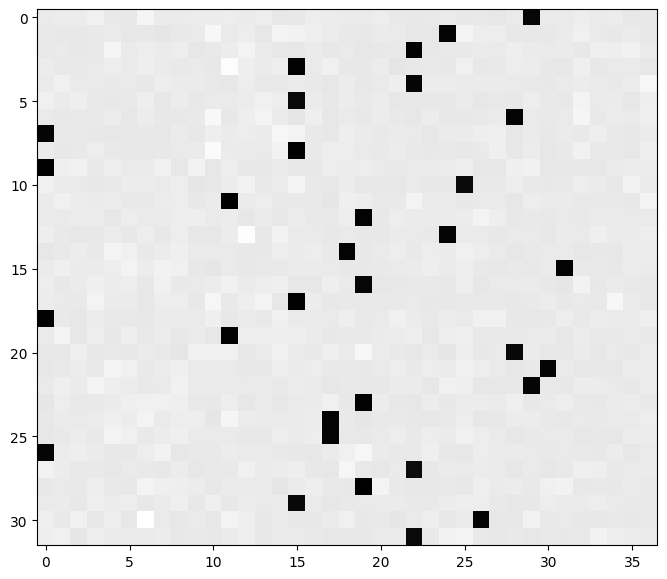

In [50]:
plt.figure(figsize=(8, 8))
plt.imshow(dlogits.detach(), cmap="gray")

## Exercise 3

Backprop through batchnorm but all in one go. To complete this challenge, look at the mathematical expression of the output of batchnorm, take the derivative w.r.t. its input, simplify the expression, and just write it out.

BatchNorm paper: https://arxiv.org/abs/1502.03167


In [51]:
# Exercise 3:

# forward pass

# before:
# bnmeani = 1/n*hprebn.sum(0, keepdim=True)
# bndiff = hprebn - bnmeani
# bndiff2 = bndiff**2
# bnvar = 1/(n-1)*(bndiff2).sum(0, keepdim=True) # note: Bessel's correction (dividing by n-1, not n)
# bnvar_inv = (bnvar + 1e-5)**-0.5
# bnraw = bndiff * bnvar_inv
# hpreact = bngain * bnraw + bnbias

# now:
hpreact_fast = (
    bngain
    * (hprebn - hprebn.mean(0, keepdim=True))
    / torch.sqrt(hprebn.var(0, keepdim=True, unbiased=True) + 1e-5)
    + bnbias
)
print("max diff:", (hpreact_fast - hpreact).abs().max())

max diff: tensor(7.1526e-07, grad_fn=<MaxBackward1>)


In [52]:
# backward pass

# before we had:
# dbnraw = bngain * dhpreact
# dbndiff = bnvar_inv * dbnraw
# dbnvar_inv = (bndiff * dbnraw).sum(0, keepdim=True)
# dbnvar = (-0.5*(bnvar + 1e-5)**-1.5) * dbnvar_inv
# dbndiff2 = (1.0/(n-1))*torch.ones_like(bndiff2) * dbnvar
# dbndiff += (2*bndiff) * dbndiff2
# dhprebn = dbndiff.clone()
# dbnmeani = (-dbndiff).sum(0)
# dhprebn += 1.0/n * (torch.ones_like(hprebn) * dbnmeani)

# calculate dhprebn given dhpreact (i.e. backprop through the batchnorm)
# (you'll also need to use some of the variables from the forward pass up above)

# todo: add explanation on derivation


# -----------------
# YOUR CODE HERE :)
# ! complicated derivation
dhprebn = (
    bngain
    * bnvar_inv
    * (dhpreact - dhpreact.mean(0) - bnraw * (dhpreact * bnraw).sum(0) / (n - 1))
)
# -----------------

cmp(
    "hprebn", dhprebn, hprebn
)  # I can only get approximate to be true, my maxdiff is 9e-10

hprebn          | exact: False | approximate: True  | maxdiff: 9.313225746154785e-10


## Exercise 4

Putting it all together!

Train the MLP neural net with your own backward pass.


In [53]:
# init
n_embd = 10  # the dimensionality of the character embedding vectors
n_hidden = 200  # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647)  # for reproducibility
C = torch.randn((vocab_size, n_embd), generator=g)
# Layer 1
W1 = (
    torch.randn((n_embd * block_size, n_hidden), generator=g)
    * (5 / 3)
    / ((n_embd * block_size) ** 0.5)
)
b1 = torch.randn(n_hidden, generator=g) * 0.1
# Layer 2
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.1
b2 = torch.randn(vocab_size, generator=g) * 0.1
# BatchNorm parameters
bngain = torch.randn((1, n_hidden)) * 0.1 + 1.0
bnbias = torch.randn((1, n_hidden)) * 0.1

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters))  # number of parameters in total
for p in parameters:
    p.requires_grad = True

# same optimization as last time
max_steps = 200000
batch_size = 32
n = batch_size  # convenience
lossi = []

# use this context manager for efficiency once your backward pass is written (TODO)
with torch.no_grad():
    # kick off optimization
    for i in range(max_steps):
        # minibatch construct
        ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
        Xb, Yb = Xtr[ix], Ytr[ix]  # batch X,Y

        # forward pass
        emb = C[Xb]  # embed the characters into vectors
        embcat = emb.view(emb.shape[0], -1)  # concatenate the vectors
        # Linear layer
        hprebn = embcat @ W1 + b1  # hidden layer pre-activation
        # BatchNorm layer
        # -------------------------------------------------------------
        bnmean = hprebn.mean(0, keepdim=True)
        bnvar = hprebn.var(0, keepdim=True, unbiased=True)
        bnvar_inv = (bnvar + 1e-5) ** -0.5
        bnraw = (hprebn - bnmean) * bnvar_inv
        hpreact = bngain * bnraw + bnbias
        # -------------------------------------------------------------
        # Non-linearity
        h = torch.tanh(hpreact)  # hidden layer
        logits = h @ W2 + b2  # output layer
        loss = F.cross_entropy(logits, Yb)  # loss function

        # backward pass
        for p in parameters:
            p.grad = None
        # loss.backward()  # use this for correctness comparisons, delete it later!

        # manual backprop! #swole_doge_meme
        # -----------------
        # YOUR CODE HERE :)
        dlogits = F.softmax(logits, 1)
        dlogits[range(n), Yb] -= 1
        dlogits /= n

        # 2nd layer
        dh = dlogits @ W2.T
        dW2 = h.T @ dlogits
        db2 = dlogits.sum(0)

        # tanh
        dhpreact = (1.0 - h**2) * dh

        # batchnorm
        dbngain = (bnraw * dhpreact).sum(0, keepdim=True)
        dbnbias = dhpreact.sum(0, keepdim=True)
        dhprebn = (
            bngain
            * bnvar_inv
            * (
                dhpreact
                - dhpreact.mean(0)
                - bnraw * (dhpreact * bnraw).sum(0) / (n - 1)
            )
        )

        # 1st layer
        dembcat = dhprebn @ W1.T
        dW1 = embcat.T @ dhprebn
        db1 = dhprebn.sum(0)

        # embedding
        demb = dembcat.view(emb.shape)
        dC = torch.zeros_like(C)
        for k in range(Xb.shape[0]):
            for j in range(Xb.shape[1]):
                ix = Xb[k, j]
                dC[ix] += demb[k, j]

        grads = [dC, dW1, db1, dW2, db2, dbngain, dbnbias]
        # -----------------

        # update
        lr = 0.1 if i < 100000 else 0.01  # step learning rate decay
        for p, grad in zip(parameters, grads):
            # p.data += (
            #     -lr * p.grad
            # )  # old way of cheems doge (using PyTorch grad from .backward())
            p.data += -lr * grad  # new way of swole doge TODO: enable

        # track stats
        if i % 10000 == 0:  # print every once in a while
            print(f"{i:7d}/{max_steps:7d}: {loss.item():.4f}")
        lossi.append(loss.log10().item())

        # if i >= 100:  # TODO: delete early breaking when you're ready to train the full net
        #     break

14407
      0/ 200000: 4.0343
  10000/ 200000: 2.3945
  20000/ 200000: 2.7327
  30000/ 200000: 2.7922
  40000/ 200000: 2.1865
  50000/ 200000: 2.5778
  60000/ 200000: 2.4809
  70000/ 200000: 2.7053
  80000/ 200000: 2.4590
  90000/ 200000: 2.7559
 100000/ 200000: 2.4929
 110000/ 200000: 1.9950
 120000/ 200000: 2.5184
 130000/ 200000: 2.0520
 140000/ 200000: 2.4519
 150000/ 200000: 2.1412
 160000/ 200000: 2.3593
 170000/ 200000: 2.2645
 180000/ 200000: 2.3248
 190000/ 200000: 2.1552


In [54]:
# useful for checking your gradients
# for p,g in zip(parameters, grads):
#   cmp(str(tuple(p.shape)), g, p)

In [55]:
# calibrate the batch norm at the end of training

with torch.no_grad():
    # pass the training set through
    emb = C[Xtr]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    # measure the mean/std over the entire training set
    bnmean = hpreact.mean(0, keepdim=True)
    bnvar = hpreact.var(0, keepdim=True, unbiased=True)

In [56]:
# evaluate train and val loss


@torch.no_grad()  # this decorator disables gradient tracking
def split_loss(split):
    x, y = {
        "train": (Xtr, Ytr),
        "val": (Xdev, Ydev),
        "test": (Xte, Yte),
    }[split]
    emb = C[x]  # (N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1)  # concat into (N, block_size * n_embd)
    hpreact = embcat @ W1 + b1
    hpreact = bngain * (hpreact - bnmean) * (bnvar + 1e-5) ** -0.5 + bnbias
    h = torch.tanh(hpreact)  # (N, n_hidden)
    logits = h @ W2 + b2  # (N, vocab_size)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())


split_loss("train")
split_loss("val")

train 2.3079583644866943
val 2.3245253562927246


In [57]:
# I achieved:
# train 2.0718822479248047
# val 2.1162495613098145

In [58]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    out = []
    context = [0] * block_size  # initialize with all ...
    while True:
        # forward pass
        emb = C[torch.tensor([context])]  # (1,block_size,d)
        embcat = emb.view(emb.shape[0], -1)  # concat into (N, block_size * n_embd)
        hpreact = embcat @ W1 + b1
        hpreact = bngain * (hpreact - bnmean) * (bnvar + 1e-5) ** -0.5 + bnbias
        h = torch.tanh(hpreact)  # (N, n_hidden)
        logits = h @ W2 + b2  # (N, vocab_size)
        # sample
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break

    print("".join(itos[i] for i in out))

dymmakakasin.
heatbenning.
moro.
ghafting.
virance.
perlangillalbuagilling.
kunda.
handogleum.
d19.
della.
montiallictimele.
siso.
chesuquereser.
tre.
kashoptyidaitimeddyodrousheensin.
pavees.
suza.
humpthoot.
bownggastum.
kombi.
